In [23]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [24]:
# 작은 텍스트 코퍼스
corpus = """hello world hello there
the quick brown fox jumps over the lazy dog
hello there hello world
a quick brown fox
the world is beautiful""".strip()

print(f"코퍼스:\n{corpus}\n")
print(f"전체 문자 수: {len(corpus)}")

# 문자 수준 토큰화
chars = sorted(set(corpus))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

print(f"\n고유 문자 수: {len(chars)}")
print(f"문자 목록 (첫 10개): {chars[:10]}")
print(f"\nchar_to_idx 예시: {dict(list(char_to_idx.items())[:10])}")

코퍼스:
hello world hello there
the quick brown fox jumps over the lazy dog
hello there hello world
a quick brown fox
the world is beautiful

전체 문자 수: 132

고유 문자 수: 28
문자 목록 (첫 10개): ['\n', ' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']

char_to_idx 예시: {'\n': 0, ' ': 1, 'a': 2, 'b': 3, 'c': 4, 'd': 5, 'e': 6, 'f': 7, 'g': 8, 'h': 9}


In [25]:
# 토큰화
tokens = [char_to_idx[ch] for ch in corpus]
print(f"토큰화 결과 (처음 50개): {tokens[:50]}")
print(f"\n원문:  {corpus[:50]}")
print(f"토큰:  {tokens[:50]}")

# 훈련 데이터: (입력, 타겟) 쌍
block_size = 8  # 한 번에 8개 문자 처리
X = []  # 입력
Y = []  # 타겟 (다음 문자)

for i in range(len(tokens) - block_size):
    X.append(tokens[i:i+block_size])
    Y.append(tokens[i+block_size])

X = np.array(X)
Y = np.array(Y)

print(f"\n훈련 데이터 크기:")
print(f"  X 형태: {X.shape} (배치, 시퀀스 길이)")
print(f"  Y 형태: {Y.shape} (배치,)")
print(f"\n예시 (처음 3개):")
for i in range(3):
    input_chars = [idx_to_char[idx] for idx in X[i]]
    target_char = idx_to_char[Y[i]]
    print(f"  입력: {''.join(input_chars)} → 타겟: {target_char}")

토큰화 결과 (처음 50개): [9, 6, 13, 13, 16, 1, 24, 16, 19, 13, 5, 1, 9, 6, 13, 13, 16, 1, 21, 9, 6, 19, 6, 0, 21, 9, 6, 1, 18, 22, 10, 4, 12, 1, 3, 19, 16, 24, 15, 1, 7, 16, 25, 1, 11, 22, 14, 17, 20, 1]

원문:  hello world hello there
the quick brown fox jumps 
토큰:  [9, 6, 13, 13, 16, 1, 24, 16, 19, 13, 5, 1, 9, 6, 13, 13, 16, 1, 21, 9, 6, 19, 6, 0, 21, 9, 6, 1, 18, 22, 10, 4, 12, 1, 3, 19, 16, 24, 15, 1, 7, 16, 25, 1, 11, 22, 14, 17, 20, 1]

훈련 데이터 크기:
  X 형태: (124, 8) (배치, 시퀀스 길이)
  Y 형태: (124,) (배치,)

예시 (처음 3개):
  입력: hello wo → 타겟: r
  입력: ello wor → 타겟: l
  입력: llo worl → 타겟: d


In [26]:
def softmax(logits):
    """소프트맥스 함수: 로짓을 확률로 변환"""
    exp_logits = np.exp(logits - np.max(logits, axis=-1, keepdims=True))  # 수치 안정성
    return exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

def cross_entropy_loss(logits, targets):
    """Cross Entropy Loss 계산
    
    logits: (배치, 어휘크기) - 모델의 원점수
    targets: (배치,) - 정답 토큰 인덱스
    """
    # 소프트맥스로 확률 계산
    probs = softmax(logits)
    
    # 배치 크기
    batch_size = logits.shape[0]
    
    # 정답에 할당한 확률
    correct_log_probs = -np.log(probs[np.arange(batch_size), targets] + 1e-8)
    
    # 평균 손실
    loss = np.mean(correct_log_probs)
    
    return loss, probs

# 테스트
logits_example = np.random.randn(4, len(chars)) * 0.01  # 매우 작은 초기값
targets_example = np.array([0, 1, 2, 3])

loss, probs = cross_entropy_loss(logits_example, targets_example)
print("Cross Entropy Loss 테스트")
print(f"  로짓 형태: {logits_example.shape}")
print(f"  타겟: {targets_example}")
print(f"  손실: {loss:.4f}")
print(f"  확률 형태: {probs.shape}")
print(f"  정답 확률 (예시): {probs[0, targets_example[0]]:.4f}")

Cross Entropy Loss 테스트
  로짓 형태: (4, 28)
  타겟: [0 1 2 3]
  손실: 3.3289
  확률 형태: (4, 28)
  정답 확률 (예시): 0.0360


In [27]:
# 모델 파라미터 초기화
vocab_size = len(chars)
embedding_dim = 8  # One-hot은 너무 크니까 저차원 임베딩 사용

# 토큰 임베딩: (어휘크기, 임베딩차원)
W_embed = np.random.randn(vocab_size, embedding_dim) * 0.01

# 출력 가중치: (임베딩차원*시퀀스길이, 어휘크기)
W_out = np.random.randn(embedding_dim * block_size, vocab_size) * 0.01
b_out = np.zeros((1, vocab_size))

print(f"임베딩 가중치: {W_embed.shape}")
print(f"출력 가중치: {W_out.shape}")
print(f"편향: {b_out.shape}")
print(f"\n초기 손실 추정 (무작위 예측): {np.log(vocab_size):.4f}")

임베딩 가중치: (28, 8)
출력 가중치: (64, 28)
편향: (1, 28)

초기 손실 추정 (무작위 예측): 3.3322


In [28]:
# 간단한 학습 루프
learning_rate = 0.1
loss_history = []

# 2 에포크 학습
for epoch in range(10):
    epoch_losses = []
    
    for i in range(len(X)):
        # 순전파: 임베딩
        X_embedded = W_embed[X[i]]  # (8, 8)
        X_flat = X_embedded.flatten()  # (64,)
        
        # 로짓 계산
        logits = np.dot(X_flat.reshape(1, -1), W_out) + b_out  # (1, 23)
        loss, probs = cross_entropy_loss(logits, Y[i:i+1])
        epoch_losses.append(loss)
        
        # 역전파 (간단한 그래디언트)
        logits_grad = probs[0].copy()
        logits_grad[Y[i]] -= 1  # 정답 클래스
        
        # 출력 가중치 그래디언트
        W_out_grad = np.outer(X_flat, logits_grad)  # (64, 23)
        b_out_grad = logits_grad.reshape(1, -1)  # (1, 23)
        
        # 파라미터 업데이트
        W_out -= learning_rate * W_out_grad
        b_out -= learning_rate * b_out_grad
    
    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)
    print(f"에포크 {epoch+1}: 평균 손실 = {avg_loss:.4f}")

print(f"\n학습 완료: {loss_history[0]:.4f} → {loss_history[-1]:.4f} (감소함!)")

에포크 1: 평균 손실 = 3.2302
에포크 2: 평균 손실 = 3.0838
에포크 3: 평균 손실 = 3.0384
에포크 4: 평균 손실 = 3.0202
에포크 5: 평균 손실 = 3.0110
에포크 6: 평균 손실 = 3.0057
에포크 7: 평균 손실 = 3.0021
에포크 8: 평균 손실 = 2.9996
에포크 9: 평균 손실 = 2.9976
에포크 10: 평균 손실 = 2.9960

학습 완료: 3.2302 → 2.9960 (감소함!)


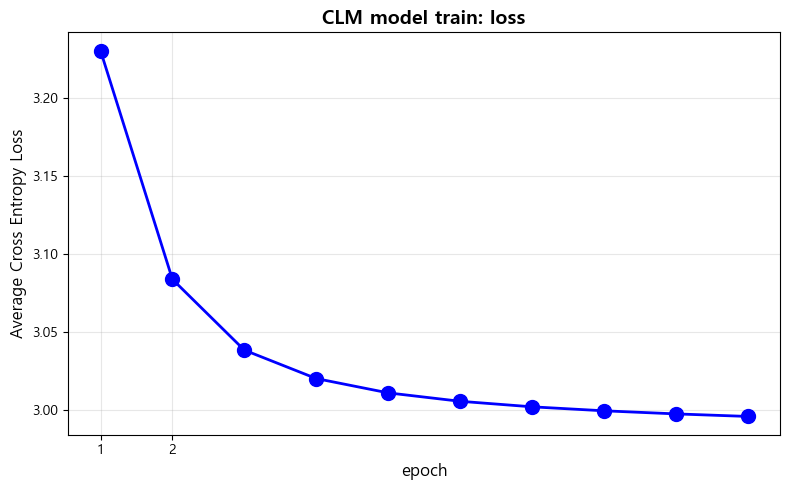


*** 학습 분석 ***
손실 감소율: 7.3%
첫 에포크 손실 (무작위 수준): 3.2302
마지막 에포크 손실 (개선됨): 2.9960


In [ ]:
# 손실 변화 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history)+1), loss_history, 'bo-', linewidth=2, markersize=10)
plt.xlabel('epoch', fontsize=12)
plt.ylabel('Average Cross Entropy Loss', fontsize=12)
plt.title('CLM model train: loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks([1, 2])
plt.tight_layout()
plt.show()

print("\n*** 학습 분석 ***")
print(f"손실 감소율: {(loss_history[0] - loss_history[-1])/loss_history[0]*100:.1f}%")
print(f"첫 에포크 손실 (무작위 수준): {loss_history[0]:.4f}")
print(f"마지막 에포크 손실 (개선됨): {loss_history[-1]:.4f}")